TESTING LOGISTIC COST FUNCTION

Test 1: Perfect predictions
Cost: 0.010050
Expected: Very small (close to 0)

Test 2: Terrible predictions (confidently wrong)
Cost: 4.605170
Expected: Very large

Test 3: Random predictions (0.5 probability)
Cost: 0.693147
Expected: 0.693147


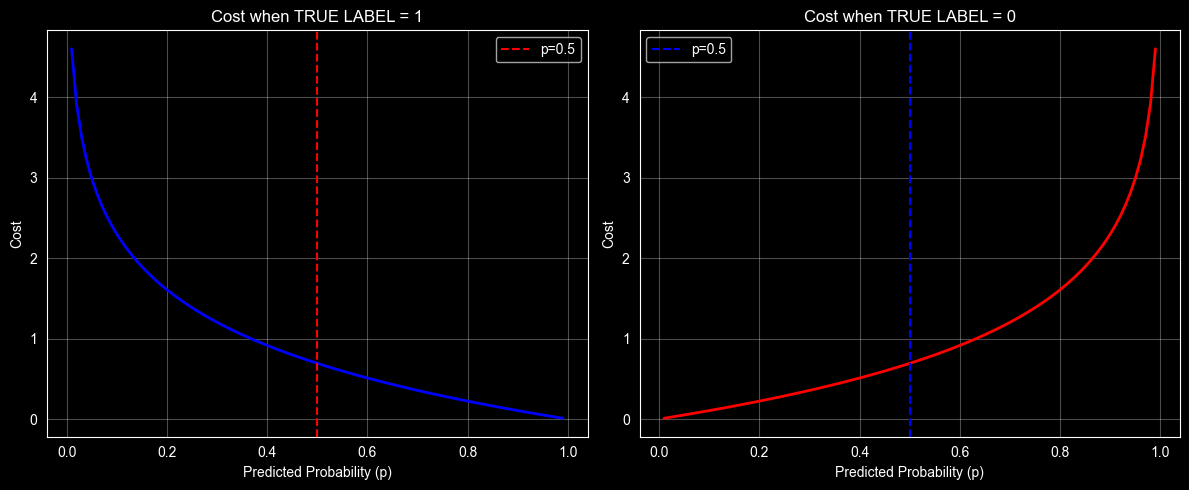

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Convert z to probability between 0 and 1"""
    return 1 / (1 + np.exp(-z))

def logistic_cost(y_true, y_pred_prob):
    """
    Calculate the cost (log loss) for logistic regression
    """
    # Number of examples
    m = len(y_true)

    # To avoid log(0) which is undefined, we add a tiny epsilon
    epsilon = 1e-15
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)

    # Calculate the cost
    cost = -1/m * np.sum(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))

    return cost

# ============================================
# TESTING  COST FUNCTION
# ============================================

print("=" * 50)
print("TESTING LOGISTIC COST FUNCTION")
print("=" * 50)

# Test Case 1: Perfect predictions
print("\nTest 1: Perfect predictions")
y_true = np.array([1, 0, 1, 0])
y_pred_prob = np.array([0.99, 0.01, 0.99, 0.01])
cost = logistic_cost(y_true, y_pred_prob)
print(f"Cost: {cost:.6f}")
print("Expected: Very small (close to 0)")

# Test Case 2: Terrible predictions
print("\nTest 2: Terrible predictions (confidently wrong)")
y_true = np.array([1, 0, 1, 0])
y_pred_prob = np.array([0.01, 0.99, 0.01, 0.99])
cost = logistic_cost(y_true, y_pred_prob)
print(f"Cost: {cost:.6f}")
print("Expected: Very large")

# Test Case 3: Random predictions (50% chance)
print("\nTest 3: Random predictions (0.5 probability)")
y_true = np.array([1, 0, 1, 0])
y_pred_prob = np.array([0.5, 0.5, 0.5, 0.5])
cost = logistic_cost(y_true, y_pred_prob)
print(f"Cost: {cost:.6f}")
print("Expected: 0.693147")

# ============================================
# VISUALIZING THE COST FUNCTION
# ============================================

plt.figure(figsize=(12, 5))

# Plot for when true label = 1
plt.subplot(1, 2, 1)
p = np.linspace(0.01, 0.99, 100)
cost_when_true_1 = -np.log(p)
plt.plot(p, cost_when_true_1, 'b-', linewidth=2)
plt.xlabel('Predicted Probability (p)')
plt.ylabel('Cost')
plt.title('Cost when TRUE LABEL = 1')
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='r', linestyle='--', label='p=0.5')
plt.legend()

# Plot for when true label = 0
plt.subplot(1, 2, 2)
p = np.linspace(0.01, 0.99, 100)
cost_when_true_0 = -np.log(1 - p)
plt.plot(p, cost_when_true_0, 'r-', linewidth=2)
plt.xlabel('Predicted Probability (p)')
plt.ylabel('Cost')
plt.title('Cost when TRUE LABEL = 0')
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='b', linestyle='--', label='p=0.5')
plt.legend()

plt.tight_layout()
plt.show()

## KEY INSIGHTS

1. When prediction is CORRECT and confident → cost is LOW (close to 0)
2. When prediction is WRONG and confident → cost is VERY HIGH
3. When prediction is uncertain (p=0.5) → cost is 0.693
4. The cost function PENALIZES confident wrong predictions heavily